In [2]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

from scipy import ndimage
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import log_loss, accuracy_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [3]:
fn = "image1-competition.hdf5"

with h5py.File(fn, "r") as f:
    data = np.array(f["data"])          # (H, W, B)
    wns = np.array(f["wns"])
    tissue_mask = np.array(f["tissue_mask"])
    classes = np.array(f["classes"])

print("data:", data.shape, data.dtype)
print("wns:", wns.shape)
print("tissue_mask:", tissue_mask.shape, tissue_mask.dtype)
print("classes:", classes.shape, classes.dtype)
print("Annotated pixels:", np.sum(classes != -1))

data: (934, 1300, 187) float32
wns: (187,)
tissue_mask: (934, 1300) bool
classes: (934, 1300) int8
Annotated pixels: 40145


In [4]:
H, W, B = data.shape

pred_r0, pred_r1 = 265, 465
pred_c0, pred_c1 = 360, 660

prediction_crop_mask = np.zeros((H, W), dtype=bool)
prediction_crop_mask[pred_r0:pred_r1, pred_c0:pred_c1] = True

usable_annotated_mask = (classes != -1) & (~prediction_crop_mask)

print("Annotated outside prediction crop:", usable_annotated_mask.sum())

Annotated outside prediction crop: 40145


In [5]:
labeled_components, num_components = ndimage.label(tissue_mask)
print("Num tissue components:", num_components)

Num tissue components: 1132


In [6]:
# koliko anotiranih pikslov ima posamezna komponenta
component_ids = np.unique(labeled_components[usable_annotated_mask])
component_ids = component_ids[component_ids != 0]

component_sizes = []
for cid in component_ids:
    cnt = np.sum((labeled_components == cid) & usable_annotated_mask)
    if cnt > 0:
        component_sizes.append((cid, cnt))

component_sizes = sorted(component_sizes, key=lambda x: x[1], reverse=True)
print("Num usable labeled components:", len(component_sizes))
print("Top 10 component sizes:", component_sizes[:10])

Num usable labeled components: 63
Top 10 component sizes: [(np.int32(110), np.int64(2592)), (np.int32(645), np.int64(2362)), (np.int32(642), np.int64(2005)), (np.int32(779), np.int64(1974)), (np.int32(535), np.int64(1728)), (np.int32(68), np.int64(1654)), (np.int32(398), np.int64(1646)), (np.int32(49), np.int64(1544)), (np.int32(538), np.int64(1481)), (np.int32(855), np.int64(1456))]


In [7]:
# greedily izberi približno 20% anotiranih pikslov za validation
target_val = int(0.2 * usable_annotated_mask.sum())

val_component_ids = []
train_component_ids = []

running = 0
toggle = True

for cid, cnt in component_sizes:
    if running < target_val and toggle:
        val_component_ids.append(cid)
        running += cnt
    else:
        train_component_ids.append(cid)
    toggle = not toggle

train_mask = np.isin(labeled_components, train_component_ids) & usable_annotated_mask
val_mask   = np.isin(labeled_components, val_component_ids) & usable_annotated_mask

print("Train annotated:", train_mask.sum())
print("Val annotated:", val_mask.sum())
print("Val ratio:", val_mask.sum() / usable_annotated_mask.sum())

Train annotated: 30693
Val annotated: 9452
Val ratio: 0.23544650641424836


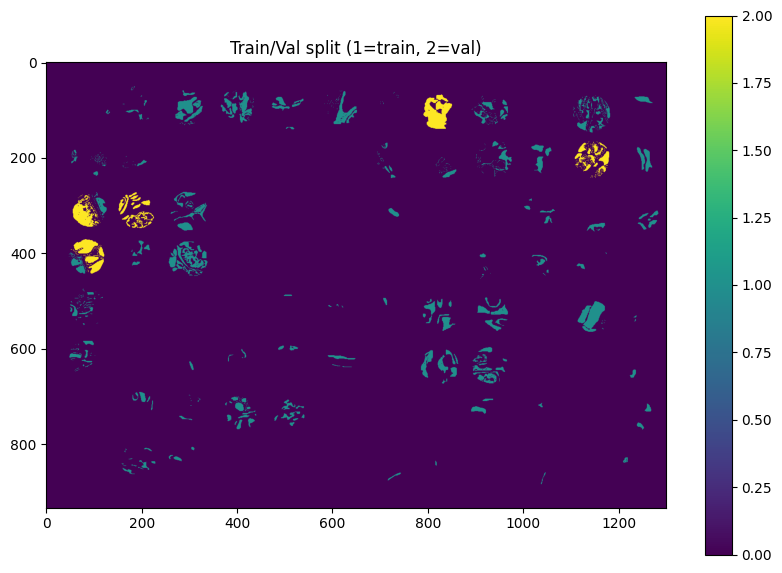

In [8]:
vis = np.zeros((H, W), dtype=np.int32)
vis[train_mask] = 1
vis[val_mask] = 2

plt.figure(figsize=(10, 7))
plt.imshow(vis, cmap="viridis")
plt.title("Train/Val split (1=train, 2=val)")
plt.colorbar()
plt.show()

In [9]:
X_train_spec = data[train_mask]   # (N_train, 187)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_spec)

pca = PCA(n_components=16, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)

print("Original spectral dim:", X_train_spec.shape[1])
print("PCA dim:", X_train_pca.shape[1])
print("Explained variance:", pca.explained_variance_ratio_.sum())

Original spectral dim: 187
PCA dim: 16
Explained variance: 0.95155203


In [10]:
data_2d = data.reshape(-1, B)
data_2d_scaled = scaler.transform(data_2d)
data_2d_pca = pca.transform(data_2d_scaled)

data_pca = data_2d_pca.reshape(H, W, 16).astype(np.float32)
print("data_pca:", data_pca.shape, data_pca.dtype)

data_pca: (934, 1300, 16) float32


In [11]:
train_coords = np.argwhere(train_mask)
val_coords = np.argwhere(val_mask)

train_labels = classes[train_mask].astype(np.int64)
val_labels = classes[val_mask].astype(np.int64)

print("train coords:", train_coords.shape)
print("val coords:", val_coords.shape)

train coords: (30693, 2)
val coords: (9452, 2)


In [12]:
class PatchDataset(Dataset):
    def __init__(self, cube, coords, labels, patch_size=17, augment=False):
        self.cube = cube
        self.coords = coords
        self.labels = labels
        self.patch_size = patch_size
        self.augment = augment
        self.pad = patch_size // 2

        # reflect padding po prostorskih dimenzijah
        self.cube_pad = np.pad(
            self.cube,
            ((self.pad, self.pad), (self.pad, self.pad), (0, 0)),
            mode="reflect"
        )

    def __len__(self):
        return len(self.coords)

    def __getitem__(self, idx):
        r, c = self.coords[idx]
        y = self.labels[idx]

        rp = r + self.pad
        cp = c + self.pad

        patch = self.cube_pad[
            rp - self.pad: rp + self.pad + 1,
            cp - self.pad: cp + self.pad + 1,
            :
        ]  # (P, P, C)

        if self.augment:
            # naključni flip/rotacija
            if np.random.rand() < 0.5:
                patch = np.flip(patch, axis=0).copy()
            if np.random.rand() < 0.5:
                patch = np.flip(patch, axis=1).copy()

            k = np.random.randint(0, 4)
            patch = np.rot90(patch, k, axes=(0, 1)).copy()

        # PyTorch pričakuje (C, H, W)
        patch = np.transpose(patch, (2, 0, 1)).astype(np.float32)

        return torch.tensor(patch), torch.tensor(y, dtype=torch.long)

In [13]:
patch_size = 17
batch_size = 256

train_ds = PatchDataset(data_pca, train_coords, train_labels, patch_size=patch_size, augment=True)
val_ds   = PatchDataset(data_pca, val_coords, val_labels, patch_size=patch_size, augment=False)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)

In [14]:
num_classes = 6
class_counts = np.bincount(train_labels, minlength=num_classes)
class_weights = class_counts.sum() / (num_classes * np.maximum(class_counts, 1))
class_weights = torch.tensor(class_weights, dtype=torch.float32)

print("Class counts:", class_counts)
print("Class weights:", class_weights)

Class counts: [ 4994  6398  3563  1041 11464  3233]
Class weights: tensor([1.0243, 0.7995, 1.4357, 4.9140, 0.4462, 1.5823])


In [15]:
class PatchCNN(nn.Module):
    def __init__(self, in_channels=16, num_classes=6):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = PatchCNN(in_channels=16, num_classes=6).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

Using device: cpu


In [17]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    all_probs = []
    all_targets = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            loss = criterion(logits, y)

            probs = torch.softmax(logits, dim=1)

            total_loss += loss.item() * x.size(0)
            all_probs.append(probs.cpu().numpy())
            all_targets.append(y.cpu().numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)

    avg_loss = total_loss / len(loader.dataset)
    ll = log_loss(all_targets, all_probs, labels=np.arange(6))
    acc = accuracy_score(all_targets, np.argmax(all_probs, axis=1))

    return avg_loss, ll, acc

In [18]:
best_val_ll = np.inf
best_state = None
patience = 8
patience_counter = 0
num_epochs = 30

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    val_loss, val_ll, val_acc = evaluate(model, val_loader, criterion, device)

    print(
        f"Epoch {epoch+1:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_logloss={val_ll:.5f} | "
        f"val_acc={val_acc:.4f}"
    )

    if val_ll < best_val_ll:
        best_val_ll = val_ll
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping.")
            break

Epoch 01 | train_loss=0.4672 | val_loss=0.6062 | val_logloss=0.39882 | val_acc=0.8485
Epoch 02 | train_loss=0.1712 | val_loss=0.6784 | val_logloss=0.40718 | val_acc=0.8704
Epoch 03 | train_loss=0.1259 | val_loss=0.7346 | val_logloss=0.44696 | val_acc=0.8833
Epoch 04 | train_loss=0.1049 | val_loss=0.5759 | val_logloss=0.40521 | val_acc=0.8944
Epoch 05 | train_loss=0.1183 | val_loss=0.6147 | val_logloss=0.45652 | val_acc=0.8526
Epoch 06 | train_loss=0.0790 | val_loss=0.4771 | val_logloss=0.33661 | val_acc=0.8961
Epoch 07 | train_loss=0.0635 | val_loss=0.5690 | val_logloss=0.33980 | val_acc=0.9020
Epoch 08 | train_loss=0.0608 | val_loss=0.7853 | val_logloss=0.47118 | val_acc=0.8806
Epoch 09 | train_loss=0.0599 | val_loss=0.6225 | val_logloss=0.36649 | val_acc=0.9059
Epoch 10 | train_loss=0.0523 | val_loss=0.9073 | val_logloss=0.49070 | val_acc=0.9072
Epoch 11 | train_loss=0.0549 | val_loss=0.7774 | val_logloss=0.48527 | val_acc=0.9098
Epoch 12 | train_loss=0.0462 | val_loss=0.7443 | val_l

In [19]:
model.load_state_dict(best_state)
print("Best val log loss:", best_val_ll)

Best val log loss: 0.33661423281144504


In [20]:
data_predict = data_pca[pred_r0:pred_r1, pred_c0:pred_c1, :]   # (200, 300, 16)
tissue_mask_predict = tissue_mask[pred_r0:pred_r1, pred_c0:pred_c1]

In [21]:
class PatchInferenceDataset(Dataset):
    def __init__(self, cube, coords, patch_size=17):
        self.cube = cube
        self.coords = coords
        self.patch_size = patch_size
        self.pad = patch_size // 2

        self.cube_pad = np.pad(
            self.cube,
            ((self.pad, self.pad), (self.pad, self.pad), (0, 0)),
            mode="reflect"
        )

    def __len__(self):
        return len(self.coords)

    def __getitem__(self, idx):
        r, c = self.coords[idx]
        rp = r + self.pad
        cp = c + self.pad

        patch = self.cube_pad[
            rp - self.pad: rp + self.pad + 1,
            cp - self.pad: cp + self.pad + 1,
            :
        ]
        patch = np.transpose(patch, (2, 0, 1)).astype(np.float32)
        return torch.tensor(patch), torch.tensor([r, c], dtype=torch.long)

In [22]:
pred_coords = np.argwhere(tissue_mask_predict)
print("Prediction tissue pixels:", len(pred_coords))

pred_ds = PatchInferenceDataset(data_predict, pred_coords, patch_size=patch_size)
pred_loader = DataLoader(pred_ds, batch_size=512, shuffle=False, num_workers=0)

Prediction tissue pixels: 26538


In [23]:
model.eval()

pred_array = np.full((200, 300, 6), 1.0 / 6, dtype=np.float32)

with torch.no_grad():
    for x, rc in pred_loader:
        x = x.to(device)
        logits = model(x)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        rc = rc.numpy()

        for i in range(len(rc)):
            r, c = rc[i]
            pred_array[r, c] = probs[i]

print(pred_array.shape, pred_array.dtype)

(200, 300, 6) float32


In [24]:
with open("patchcnn_pca16.npy", "wb") as f:
    np.save(f, pred_array.astype(np.float32))

print("Saved patchcnn_pca16.npy")

Saved patchcnn_pca16.npy
